 ## K-Means Clustering Algorithms Implementations

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [3]:
X,y = make_blobs(n_samples=1000,centers=3,n_features=2,random_state=23)

In [4]:
X.shape

(1000, 2)

In [14]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,Y_test = train_test_split(
    X,y,test_size=0.33,random_state=42
)

In [23]:
from sklearn.cluster import KMeans

# Elbow Method
wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42)
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

In [24]:
wcss

[34827.57682552022,
 7935.4372861454185,
 1319.2730531585607,
 1140.467788465513,
 1007.7307855664319,
 856.4010480159848,
 773.3007886035953,
 680.0890826946348,
 647.303421890592,
 597.6597265798263]

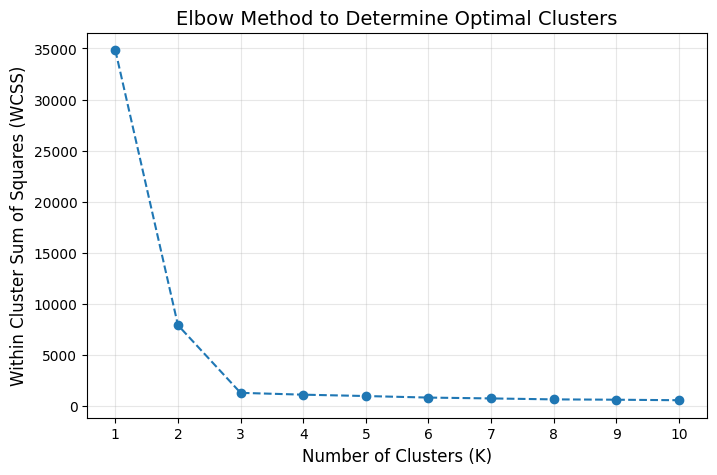

In [27]:
# Ploting Elbow Curve
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o', linestyle='--')

plt.title("Elbow Method to Determine Optimal Clusters", fontsize=14)
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Within Cluster Sum of Squares (WCSS)", fontsize=12)

plt.xticks(range(1,11))
plt.grid(alpha=0.3)

plt.show()

In [32]:
kmeans = KMeans(n_clusters=3,init="k-means++")
y_labels=kmeans.fit_predict(X_train)

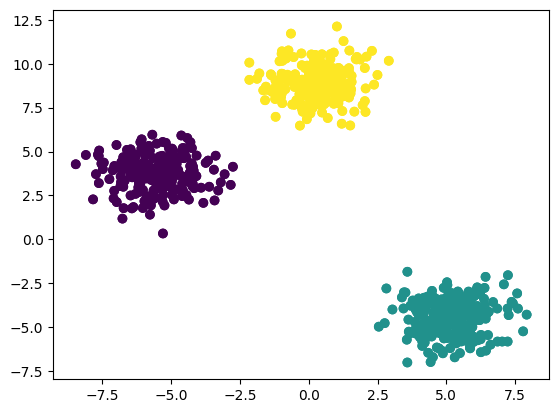

In [34]:
plt.scatter(X_train[:,0],X_train[:,1],c=y_labels)
plt.show()

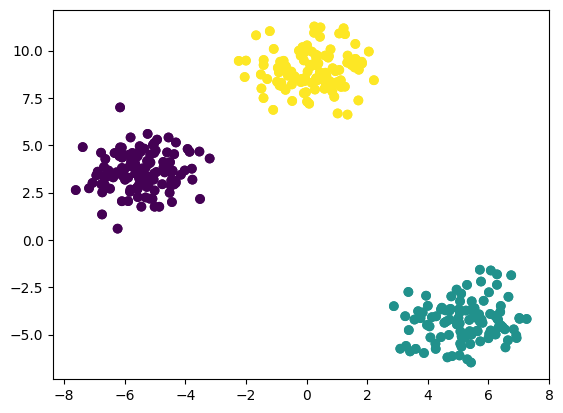

In [38]:
y_test_label = kmeans.predict(X_test)
plt.scatter(X_test[:,0],X_test[:,1],c=y_test_label)
plt.show()

In [40]:
## Now we will use knee locator as it will automate the cluster from its own 
!pip install kneed

Defaulting to user installation because normal site-packages is not writeable


In [42]:
from kneed import KneeLocator

In [43]:
kl = KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')
print(f"Number of Clusters :",kl.elbow)

Number of Clusters : 3


In [45]:
## Performace Metrics
from sklearn.metrics import silhouette_score

In [51]:
silhouette_coefficients=[]
for k in range(2,11):
    Kmeans = KMeans(n_clusters=k,init="k-means++")
    Kmeans.fit(X_train)
    score=silhouette_score(X_train,Kmeans.labels_)
    silhouette_coefficients.append(score)

In [52]:
silhouette_coefficients

[0.7281443868598331,
 0.8071181203797672,
 0.6523561521723142,
 0.47285914997401307,
 0.49899105752254436,
 0.32296234007969044,
 0.3249072285662077,
 0.34055714439454143,
 0.34315502882487]

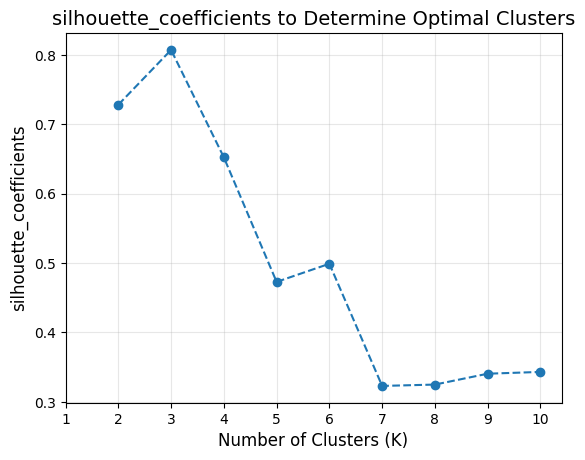

In [54]:
# Ploting Elbow Curve

plt.plot(range(2,11), silhouette_coefficients, marker='o', linestyle='--')

plt.title("silhouette_coefficients to Determine Optimal Clusters", fontsize=14)
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("silhouette_coefficients", fontsize=12)

plt.xticks(range(1,11))
plt.grid(alpha=0.3)

plt.show()